# HuPR Dataset introduction and preprocessing

----

## Introduction

**Paper:** S.-P. Lee, N. P. Kini, W.-H. Peng, C.-W. Ma, and J.-N. Hwang, “HuPR: a benchmark for human pose estimation using millimeter wave radar,” in Proceedings of the IEEE/CVF winter conference on applications of computer vision (WACV), Jan. 2023, pp. 5715–5724.


**Open-sourced code and dataset:** [HuPR](https://github.com/robert80203/HuPR-A-Benchmark-for-Human-Pose-Estimation-Using-Millimeter-Wave-Radar)

**Basic information about the dataset and the training:**
- The dataset contains total 235 video sequences, each being 1-minute long.
- We take 193 video sequences for training, 21 for validation, and 21 for test. 
- The **2D groundtruth keypoints** for training video sequences are generated from the RGB frames by the state-of-the-art 2D human pose estimation network, HRNet [22], which is pre-trained on MPII dataset [1]. 

## Preprocessing

### The structure of the downloaded dataset
(The downloading need to be authorized by the authors of the dataset, check the above open-source link for more information)

```
HuPR
├── annotations  # Annotations for the dataset, contains three files for training, validation, and test
├── frames.zip   # the rgb frames
├── radar        # the ADC radar data
```

### unzip all the files

In [3]:
# import os

# # list the files in annotations directory
# annotations = os.listdir('annotations')
# print(annotations)

# # list the files in radar directory
# radar = os.listdir('radar')
# print(radar)


['hrnet_annot_test.json', 'hrnet_annot_val.json', 'hrnet_annot_train.json']
['seq_271-276.zip', 'seq_181-190.zip', 'seq_61-70.zip', 'seq_241-250.zip', 'seq_111-120.zip', 'seq_1-10.zip', 'seq_211-220.zip', 'seq_261-270.zip', 'seq_191-200.zip', 'seq_161-170.zip', 'seq_81-90.zip', 'seq_51-60.zip', 'seq_101-110.zip', 'seq_91-100.zip', 'seq_121-130.zip', 'seq_221-230.zip', 'seq_171-180.zip', 'seq_151-160.zip', 'seq_71-80.zip', 'seq_11-20.zip', 'seq_31-40.zip', 'seq_201-210.zip', 'seq_21-30.zip', 'seq_41-50.zip', 'seq_131-140.zip', 'seq_231-240.zip', 'seq_141-150.zip', 'seq_251-260.zip']


In [ ]:
# os.system(f'unzip frames.zip')

In [4]:
# # Unzip the files in radar directory and save them in radar_unzipped directory
# os.system('mkdir radar_unzipped')
# for file in radar:
#     os.system(f'unzip radar/{file} -d radar_unzipped')
#     print(f'Unzipped {file}')


Archive:  radar/seq_271-276.zip
   creating: radar_unzipped/single_271/
   creating: radar_unzipped/single_271/hori/
  inflating: radar_unzipped/single_271/hori/adc_data.bin  
   creating: radar_unzipped/single_271/vert/
  inflating: radar_unzipped/single_271/vert/adc_data.bin  
   creating: radar_unzipped/single_272/
   creating: radar_unzipped/single_272/hori/
  inflating: radar_unzipped/single_272/hori/adc_data.bin  
   creating: radar_unzipped/single_272/vert/
  inflating: radar_unzipped/single_272/vert/adc_data.bin  
   creating: radar_unzipped/single_273/
   creating: radar_unzipped/single_273/hori/
  inflating: radar_unzipped/single_273/hori/adc_data.bin  
   creating: radar_unzipped/single_273/vert/
  inflating: radar_unzipped/single_273/vert/adc_data.bin  
   creating: radar_unzipped/single_274/
   creating: radar_unzipped/single_274/vert/
  inflating: radar_unzipped/single_274/vert/adc_data.bin  
   creating: radar_unzipped/single_274/hori/
  inflating: radar_unzipped/single_

**After the unziping, we can see the following structure:**

```
HuPR
├── annotations
├── frames
├── frames.zip
├── radar
├── radar_unzipped
└── README.ipynb
```

*We will delete the zip files to save the storage space*
```
HuPR
├── annotations
├── frames
├── radar_unzipped
└── README.ipynb
```


<p style="color:red;">Finnaly, we will have the following structure:</p>

```
HuPR
├── annotations            # Annotations for the dataset, contains three files for training, validation, and test
├── frame_generate.log     # log file for the frame generation
├── frames                 # the rgb frames
├── preparing_dataset.py   # the script for generating the radar_maps
├── radar_maps             # the radar_maps generated from the radar data (used for experiments), generated by the above script: preparing_dataset.py
├── radar_unzipped         # the raw ADC radar data
└── README.ipynb           # this file
```

**The rest of this README demonstrate how to generate the radar_maps from the raw ADC radar data. (can be skipped if you are not interested in the radar data)**

-------

-----

### Preprocessing the radar data

#### Anotation files

In [1]:
# load the annotation jason file and check the informations

import json
import os
import cv2
import numpy as np

# load the annotation json file
with open('annotations/hrnet_annot_train.json') as f:
    data = json.load(f)
print('the number of the samples in trainset is: ', len(data))

with open('annotations/hrnet_annot_test.json') as f:
    data = json.load(f)
print('the number of the samples in testset is: ', len(data))

with open('annotations/hrnet_annot_val.json') as f:
    data = json.load(f)
print('the number of the samples in valset is: ', len(data))



element = data[1]
frame = element[1]
print("the items in the annotation file are: ", frame.keys())

# the index of the train, test, val samples are stored in: HuPR-A-Benchmark-for-Human-Pose-Estimation-Using-Millimeter-Wave-Radar/config/mscsa_prgcn.yaml

the number of the samples in trainset is:  193
the number of the samples in testset is:  21
the number of the samples in valset is:  21
the items in the annotation file are:  dict_keys(['image', 'joints', 'bbox'])


In [2]:
element = data[1]

frame = element[1]
print("the items in the annotation file are: ", frame.keys())
print(frame['image'])


frame = element[2]
print("the items in the annotation file are: ", frame.keys())
print(frame['image'])

the items in the annotation file are:  dict_keys(['image', 'joints', 'bbox'])
1.jpg
the items in the annotation file are:  dict_keys(['image', 'joints', 'bbox'])
2.jpg


In [3]:
# the index of the train, test, val samples are stored in: HuPR-A-Benchmark-for-Human-Pose-Estimation-Using-Millimeter-Wave-Radar/config/mscsa_prgcn.yaml ::

testName=[15, 16, 38, 40, 41, 42,
               17, 39,  244, 245, 246, 249, 250, 251, 252, 253, 254,
               247, 248, 255, 256]
valName =[1, 14, 34, 57, 65,  98,
            56, 99, 159, 178,
            101, 120, 137, 156, 161, 164, 181, 194, 197, 205, 257]
trainName= [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 18, 19, 20, 21, 
            22, 23, 24, 25, 26, 27, 28, 29, 30, 33, 35, 36, 37, 43, 
            44, 45, 46, 47, 48, 49, 50, 51, 52, 58, 59, 60, 61, 62, 
            63, 64, 66, 71, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 
            84, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97,
            31, 32, 53, 54, 55, 67, 68, 69, 70, 72, 85, 86, 100, 157, 158, 
            160, 167, 168, 169, 170, 177, 179, 180, 187, 188, 189, 190, 
            228, 229, 230, 259, 260, 263, 264, 269, 270, 273, 274,
            102, 103, 104, 105, 106, 107, 108, 109, 110, 119, 121, 122, 
            123, 124, 133, 134, 135, 138, 147, 148, 149, 150, 151, 152, 
            153, 154, 155, 162, 163, 165, 166, 171, 172, 173, 174, 175, 
            176, 182, 183, 184, 185, 186, 191, 192, 193, 195, 196, 198, 
            199, 200, 201, 202, 203, 204, 206, 207, 208, 209, 210, 211, 
            212, 213, 215, 216, 223, 224, 225, 226, 231, 232, 233, 234, 
            235, 236, 258, 261, 262, 265, 266, 267, 268, 271, 272, 275, 
            276]
# the above indexes are the samples in the data file and connect to the annotations

print("the number of samples in the train, test, val samples are: ")
print(len(trainName))
print(len(testName))
print(len(valName))

print("the total number of samples in the data file is: ", len(trainName)+len(testName)+len(valName))

# what number is missing from 1 to 276 in the train, test, val samples
trainName = set(trainName)
testName = set(testName)
valName = set(valName)
allName = set(range(1, 277))
union = trainName.union(testName.union(valName))
missing = allName - union
missing = list(missing)
missing.sort()
print("the missing samples (unused in their paper) from 1 to 276 are: ")
print(missing)

the number of samples in the train, test, val samples are: 
193
21
21
the total number of samples in the data file is:  235
the missing samples (unused in their paper) from 1 to 276 are: 
[82, 111, 112, 113, 114, 115, 116, 117, 118, 125, 126, 127, 128, 129, 130, 131, 132, 136, 139, 140, 141, 142, 143, 144, 145, 146, 214, 217, 218, 219, 220, 221, 222, 227, 237, 238, 239, 240, 241, 242, 243]


#### Preprocessing the radar data (IWR1843)
(based on the script in HuPR-A-Benchmark-for-Human-Pose-Estimation-Using-Millimeter-Wave-Radar/preprocessing/process_iwr1843.py)

In [4]:
radar_files = os.listdir('radar_unzipped')
radar_files.sort()
radar_files_path = [f'radar_unzipped/{file}' for file in radar_files]
print(radar_files_path)

['radar_unzipped/single_1', 'radar_unzipped/single_10', 'radar_unzipped/single_100', 'radar_unzipped/single_101', 'radar_unzipped/single_102', 'radar_unzipped/single_103', 'radar_unzipped/single_104', 'radar_unzipped/single_105', 'radar_unzipped/single_106', 'radar_unzipped/single_107', 'radar_unzipped/single_108', 'radar_unzipped/single_109', 'radar_unzipped/single_11', 'radar_unzipped/single_110', 'radar_unzipped/single_111', 'radar_unzipped/single_112', 'radar_unzipped/single_113', 'radar_unzipped/single_114', 'radar_unzipped/single_115', 'radar_unzipped/single_116', 'radar_unzipped/single_117', 'radar_unzipped/single_118', 'radar_unzipped/single_119', 'radar_unzipped/single_12', 'radar_unzipped/single_120', 'radar_unzipped/single_121', 'radar_unzipped/single_122', 'radar_unzipped/single_123', 'radar_unzipped/single_124', 'radar_unzipped/single_125', 'radar_unzipped/single_126', 'radar_unzipped/single_127', 'radar_unzipped/single_128', 'radar_unzipped/single_129', 'radar_unzipped/si

**processing one sample**

In [5]:
sample1_path = radar_files_path[0]
horizontal_radar_frame = radar_files_path[0] + '/hori'
vertical_radar_frame = radar_files_path[0] + '/vert'

print(horizontal_radar_frame)
print(vertical_radar_frame)

radar_unzipped/single_1/hori
radar_unzipped/single_1/vert


Load the data frame from the bin file under the LVDS format, and reshape it to the complex format.

```python
def getadcDataFromDCA1000(self, fileName):
    adcData = np.fromfile(fileName+'/adc_data.bin', dtype=np.int16)
    fileSize = adcData.shape[0]
    adcData = adcData.reshape(-1, self.numLanes*2).transpose()
    # # for complex data
    fileSize = int(fileSize/2)
    LVDS = np.zeros((2, fileSize))  # seperate each LVDS lane into rows

    temp = np.empty((adcData[0].size + adcData[1].size), dtype=adcData[0].dtype)
    temp[0::2] = adcData[0]
    temp[1::2] = adcData[1]
    LVDS[0] = temp
    temp = np.empty((adcData[2].size + adcData[3].size), dtype=adcData[2].dtype)
    temp[0::2] = adcData[2]
    temp[1::2] = adcData[3]
    LVDS[1] = temp

    adcData = np.zeros((self.numRX, int(fileSize/self.numRX)), dtype = 'complex_')
    iter = 0
    for i in range(0, fileSize, self.numADCSamples * 4):
        adcData[0][iter:iter+self.numADCSamples] = LVDS[0][i:i+self.numADCSamples] + np.sqrt(-1+0j)*LVDS[1][i:i+self.numADCSamples]
        adcData[1][iter:iter+self.numADCSamples] = LVDS[0][i+self.numADCSamples:i+self.numADCSamples*2] + np.sqrt(-1+0j)*LVDS[1][i+self.numADCSamples:i+self.numADCSamples*2]
        adcData[2][iter:iter+self.numADCSamples] = LVDS[0][i+self.numADCSamples*2:i+self.numADCSamples*3] + np.sqrt(-1+0j)*LVDS[1][i+self.numADCSamples*2:i+self.numADCSamples*3]
        adcData[3][iter:iter+self.numADCSamples] = LVDS[0][i+self.numADCSamples*3:i+self.numADCSamples*4] + np.sqrt(-1+0j)*LVDS[1][i+self.numADCSamples*3:i+self.numADCSamples*4]
        iter = iter + self.numADCSamples

    #correct reshape
    adcDataReshape = adcData.reshape(self.numRX, -1, self.numADCSamples)
    print('Shape of radar data:', adcDataReshape.shape)
    return adcDataReshape
```

Loading .bin file

In [6]:
adcData = np.fromfile(horizontal_radar_frame+'/adc_data.bin', dtype=np.int16)
fileSize = adcData.shape[0]

Converting to the complex format in numpy array

In [7]:
numLanes = 2
numRX = 4
numADCSamples = 256


adcData = adcData.reshape(-1, numLanes*2).transpose()
fileSize = int(fileSize/2)
LVDS = np.zeros((2, fileSize))  # seperate each LVDS lane into rows

temp = np.empty((adcData[0].size + adcData[1].size), dtype=adcData[0].dtype)
temp[0::2] = adcData[0]
temp[1::2] = adcData[1]
LVDS[0] = temp
temp = np.empty((adcData[2].size + adcData[3].size), dtype=adcData[2].dtype)
temp[0::2] = adcData[2]
temp[1::2] = adcData[3]
LVDS[1] = temp

adcData = np.zeros((numRX, int(fileSize/numRX)), dtype = 'complex_')
iter = 0
for i in range(0, fileSize, numADCSamples * 4):
    adcData[0][iter:iter+numADCSamples] = LVDS[0][i:i+numADCSamples] + np.sqrt(-1+0j)*LVDS[1][i:i+numADCSamples]
    adcData[1][iter:iter+numADCSamples] = LVDS[0][i+numADCSamples:i+numADCSamples*2] + np.sqrt(-1+0j)*LVDS[1][i+numADCSamples:i+numADCSamples*2]
    adcData[2][iter:iter+numADCSamples] = LVDS[0][i+numADCSamples*2:i+numADCSamples*3] + np.sqrt(-1+0j)*LVDS[1][i+numADCSamples*2:i+numADCSamples*3]
    adcData[3][iter:iter+numADCSamples] = LVDS[0][i+numADCSamples*3:i+numADCSamples*4] + np.sqrt(-1+0j)*LVDS[1][i+numADCSamples*3:i+numADCSamples*4]
    iter = iter + numADCSamples

#correct reshape
adcDataReshape = adcData.reshape(numRX, -1, numADCSamples)

print('Shape of radar data (#_of_Rx, data_len, numADCSamples):', adcDataReshape.shape)
print('Type of the data: ' ,adcDataReshape[0,0,0])

Shape of radar data (#_of_Rx, data_len, numADCSamples): (4, 115200, 256)
Type of the data:  (-63-88j)


Extracting one frame in the sample

In [8]:
framePerSecond = 10
duration = 60
numFrame = framePerSecond * duration
numChirp = 64 * 3 

for idxFrame in range(0,numFrame):
    frame = adcDataReshape[:, numChirp*(idxFrame):numChirp*(idxFrame+1), 0:numADCSamples]
    print('The frame shape (#_of_Rx, #_of_chirps x #_of_Tx, numADCSamples): ',frame.shape)
    break 

The frame shape (#_of_Rx, #_of_chirps x #_of_Tx, numADCSamples):  (4, 192, 256)


Sperating the vertical and horizontal links based on the IWR1843 radar antenna configuration (3Tx 4Rx)

In [9]:
idxProcChirp = 64  # this is the number of the transmitted chirps actually processed by the radar

# horizontal
dataRadar = np.zeros((numRX*2, idxProcChirp, numADCSamples), dtype='complex_')
# vertical
dataRadar2 = np.zeros((numRX, idxProcChirp, numADCSamples), dtype='complex_')

# Process radar data with TDM-MIMO
for idxRX in range(numRX):
    for idxChirp in range(numChirp):
        if idxChirp % 3 == 0:
            dataRadar[idxRX, idxChirp//3] = frame[idxRX, idxChirp]
        if idxChirp % 3 == 1:
            dataRadar2[idxRX, idxChirp//3] = frame[idxRX, idxChirp]
        elif idxChirp % 3 == 2:
            dataRadar[idxRX+4, idxChirp//3] = frame[idxRX, idxChirp]

print('dataRadar :: Shape of the horizontal links data (#_of_links, #_of_chirps, numADCSamples): ', dataRadar.shape)
print('dataRadar2 :: Shape of the vertical links data (#_of_links, #_of_chirps, numADCSamples): ', dataRadar2.shape)


dataRadar :: Shape of the horizontal links data (#_of_links, #_of_chirps, numADCSamples):  (8, 64, 256)
dataRadar2 :: Shape of the vertical links data (#_of_links, #_of_chirps, numADCSamples):  (4, 64, 256)


In [10]:
def clutterRemoval(input_val, axis=0):
    """Perform basic static clutter removal by removing the mean from the input_val on the specified doppler axis.
    Args:
        input_val (ndarray): Array to perform static clutter removal on. Usually applied before performing doppler FFT.
            e.g. [num_chirps, num_vx_antennas, num_samples], it is applied along the first axis.
        axis (int): Axis to calculate mean of pre-doppler.
    Returns:
        ndarray: Array with static clutter removed.
    """
    # Reorder the axes
    reordering = np.arange(len(input_val.shape))
    reordering[0] = axis
    reordering[axis] = 0
    input_val = input_val.transpose(reordering)

    # Apply static clutter removal
    mean = input_val.transpose(reordering).mean(0)
    output_val = input_val - np.expand_dims(mean, axis=0)
    out = output_val.transpose(reordering)
    return out 

Clutter removal

In [11]:
# step1: clutter removal
dataRadar = np.transpose(dataRadar, (1, 0, 2))
dataRadar = clutterRemoval(dataRadar, axis=0)
dataRadar = np.transpose(dataRadar, (1, 0, 2))
dataRadar2 = np.transpose(dataRadar2, (1, 0, 2))
dataRadar2 = clutterRemoval(dataRadar2, axis=0)
dataRadar2 = np.transpose(dataRadar2, (1, 0, 2))

print('dataRadar :: Shape of the horizontal links data after clutter removal (#_of_links, #_of_chirps, numADCSamples): ', dataRadar.shape)
print('dataRadar2 :: Shape of the vertical links data after clutter removal (#_of_links, #_of_chirps, numADCSamples): ', dataRadar2.shape)

dataRadar :: Shape of the horizontal links data after clutter removal (#_of_links, #_of_chirps, numADCSamples):  (8, 64, 256)
dataRadar2 :: Shape of the vertical links data after clutter removal (#_of_links, #_of_chirps, numADCSamples):  (4, 64, 256)


Range-doppler processing

In [12]:
# step2: range-doppler FFT
for idxRX in range(numRX * 2):
    dataRadar[idxRX, :, :] = np.fft.fft2(dataRadar[idxRX, :, :])
for idxRX in range(numRX * 1):
    dataRadar2[idxRX, :, :] = np.fft.fft2(dataRadar2[idxRX, :, :])
    
print('dataRadar :: Shape of the horizontal links data after range-doppler FFT (#_of_links, #_of_chirps, numADCSamples): ', dataRadar.shape)
print('dataRadar2 :: Shape of the vertical links data after range-doppler FFT (#_of_links, #_of_chirps, numADCSamples): ', dataRadar2.shape)

dataRadar :: Shape of the horizontal links data after range-doppler FFT (#_of_links, #_of_chirps, numADCSamples):  (8, 64, 256)
dataRadar2 :: Shape of the vertical links data after range-doppler FFT (#_of_links, #_of_chirps, numADCSamples):  (4, 64, 256)


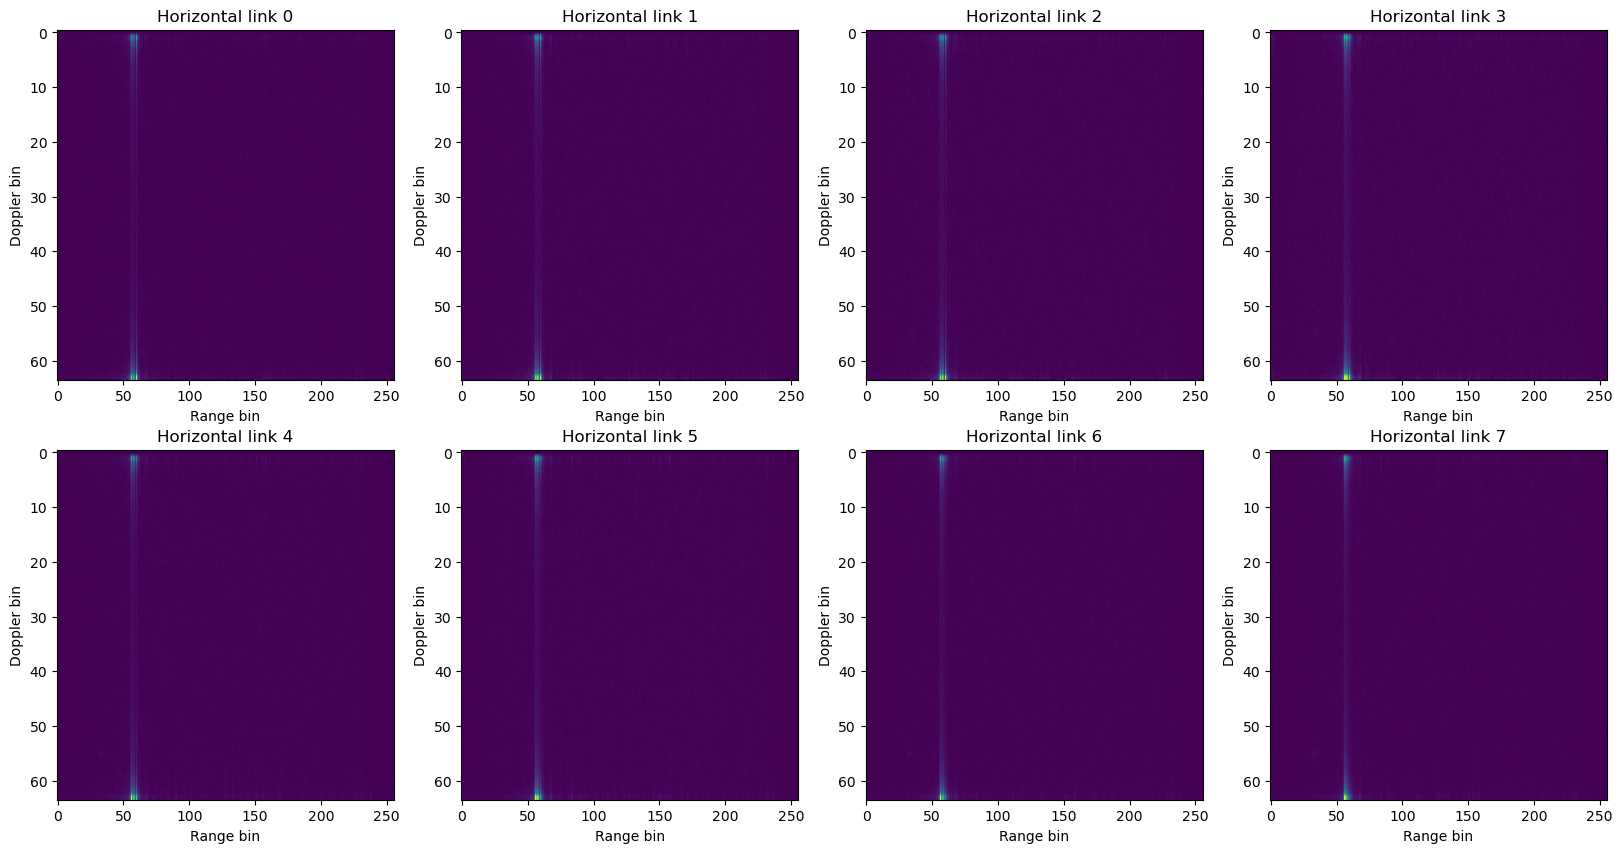

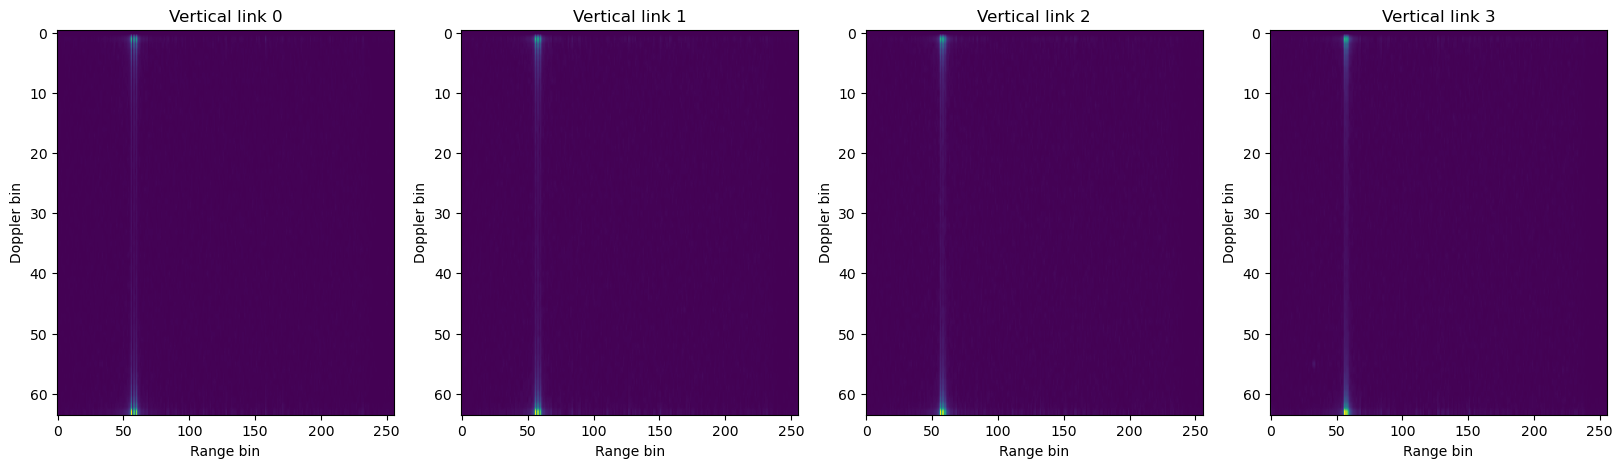

In [13]:
# visulizing the range doppler maps for the horizontal and vertical links
# visulizing the maps of the eight horizontal links in one figure with 8 subplots
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.abs(dataRadar[i*4+j, :, :]), aspect='auto')
        axs[i, j].set_title(f'Horizontal link {i*4+j}')
        axs[i, j].set_xlabel('Range bin')
        axs[i, j].set_ylabel('Doppler bin')
plt.show()

# visulizing the maps of the four vertical links in one figure with 4 subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    axs[i].imshow(np.abs(dataRadar2[i, :, :]), aspect='auto')
    axs[i].set_title(f'Vertical link {i}')
    axs[i].set_xlabel('Range bin')
    axs[i].set_ylabel('Doppler bin')
plt.show()


Adding angle FFT

In [14]:
# 1. padding with 0 for the azimuth dimension

adcRatio = 4
numAngleBins = numADCSamples//adcRatio
 
# padding with 0 to make the data into the same shape and get better frequency resolution
padding = ((0, numAngleBins - dataRadar.shape[0]), (0,0), (0,0))
dataRadar = np.pad(dataRadar, padding, mode='constant')
print('dataRadar :: Shape of the horizontal links data after padding (#_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins): ', dataRadar.shape)

# padding with 0 to make the data into the same shape and get better frequency resolution
padding2 = ((2, numAngleBins - 4 - 2), (0,0), (0,0))
dataRadar2 = np.pad(dataRadar2, padding2, mode='constant')
print('dataRadar2 :: Shape of the vertical links data after padding (#_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins): ', dataRadar2.shape)

dataRadar :: Shape of the horizontal links data after padding (#_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins):  (64, 64, 256)
dataRadar2 :: Shape of the vertical links data after padding (#_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins):  (64, 64, 256)


In [15]:
# 2. stacking the horizontal and vertical links and padding with 0s to calculate the elevation angle

numEleBins = 8

dataMerge = np.stack((dataRadar, dataRadar2)) # stack the horizontal and vertical links to calculate the elevation angle
# padding with 0 to make the data into the same shape and get better frequency resolution
paddingEle = ((0, numEleBins - dataMerge.shape[0]), (0,0), (0,0), (0,0))
dataMerge = np.pad(dataMerge, paddingEle, mode='constant')
print('dataMerge :: Shape of radar data after stacking (#_of_elevation_bins, #_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins):', dataMerge.shape)

dataMerge :: Shape of radar data after stacking (#_of_elevation_bins, #_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins): (8, 64, 64, 256)


In [16]:
# 3. calculating the elevation and azimuth angles by taking the FFT along the elevation and azimuth axis

for idxChirp in range(idxProcChirp):
    for idxADC in range(numADCSamples):
        # calculating the elevation angle by taking the FFT along the elevation axis
        dataMerge[:, 2, idxChirp, idxADC] = np.fft.fft(dataMerge[:, 2, idxChirp, idxADC])
        dataMerge[:, 3, idxChirp, idxADC] = np.fft.fft(dataMerge[:, 3, idxChirp, idxADC])
        dataMerge[:, 4, idxChirp, idxADC] = np.fft.fft(dataMerge[:, 4, idxChirp, idxADC])
        dataMerge[:, 5, idxChirp, idxADC] = np.fft.fft(dataMerge[:, 5, idxChirp, idxADC])
        for idxEle in range(numEleBins):
            # calculating the azimuth angle by taking the FFT along the azimuth axis
            dataMerge[idxEle, :, idxChirp, idxADC] = np.fft.fft(dataMerge[idxEle, :, idxChirp, idxADC])

print('dataMerge :: Shape of radar data after angle fft (#_of_elevation_bins, #_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins):', dataMerge.shape)

dataMerge :: Shape of radar data after angle fft (#_of_elevation_bins, #_of_azimuth_bins, #_of_velocity_bins, #_of_range_bins): (8, 64, 64, 256)


In [17]:
# 4. select specific area of targeting ranges and shift the velocity bin to the center (0 velocity)

idxADCSpecific = [i for i in range(94, 30, -1)] # 84, 20
# shift the velocity information
dataTemp = np.zeros((idxProcChirp, numADCSamples//adcRatio, numAngleBins, numEleBins), dtype='complex_')

for idxEle in range(numEleBins):
    for idxRX in range(numAngleBins):
        for idxADC in range(numADCSamples//adcRatio):
            dataTemp[:, idxADC, idxRX, idxEle] = dataMerge[idxEle, idxRX, :, idxADCSpecific[idxADC]]
            dataTemp[:, idxADC, idxRX, idxEle] = np.fft.fftshift(dataTemp[:, idxADC, idxRX, idxEle], axes=(0))
            
print('dataTemp :: Shape of radar data after selecting specific area of range (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins):', dataTemp.shape)

dataTemp :: Shape of radar data after selecting specific area of range (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins): (64, 64, 64, 8)


In [18]:
# 5. select specific velocity information: the center 1/4 of the velocity information (i.e., the low speed area)

numGroupChirp = 4
dataFFTGroup = np.zeros((idxProcChirp//numGroupChirp, numADCSamples//adcRatio, numAngleBins, numEleBins), dtype='complex_')
    
def postProcessFFT3D(dataFFT):
    dataFFT = np.fft.fftshift(dataFFT, axes=(0, 1,))
    dataFFT = np.transpose(dataFFT, (2, 0, 1))
    dataFFT = np.flip(dataFFT, axis=(1, 2))
    return dataFFT
    
# select specific velocity information: the center 1/4 of the velocity information (i.e., the low speed area)
chirpPad = idxProcChirp//numGroupChirp
i = 0
for idxChirp in range(idxProcChirp//2 - chirpPad//2, idxProcChirp//2 + chirpPad//2):
    dataFFTGroup[i, :, :, :] = postProcessFFT3D(np.transpose(dataTemp[idxChirp, :, :, :], (1, 2, 0)))
    # shape chagne: 
    # (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins) ->
    # (#_of_velocity_bins, #_of_azimuth_bins, #_of_elevation_bins, #_of_range_bins) ->
    # (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins)
    i += 1

print('dataFFTGroup :: Shape of radar data after selecting specific velocity information (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins):', dataFFTGroup.shape)

dataFFTGroup :: Shape of radar data after selecting specific velocity information (#_of_velocity_bins, #_of_range_bins, #_of_azimuth_bins, #_of_elevation_bins): (16, 64, 64, 8)


In [19]:
print(dataFFTGroup[3,4,5,1])

(-672.6709983183671+2535.200625679987j)


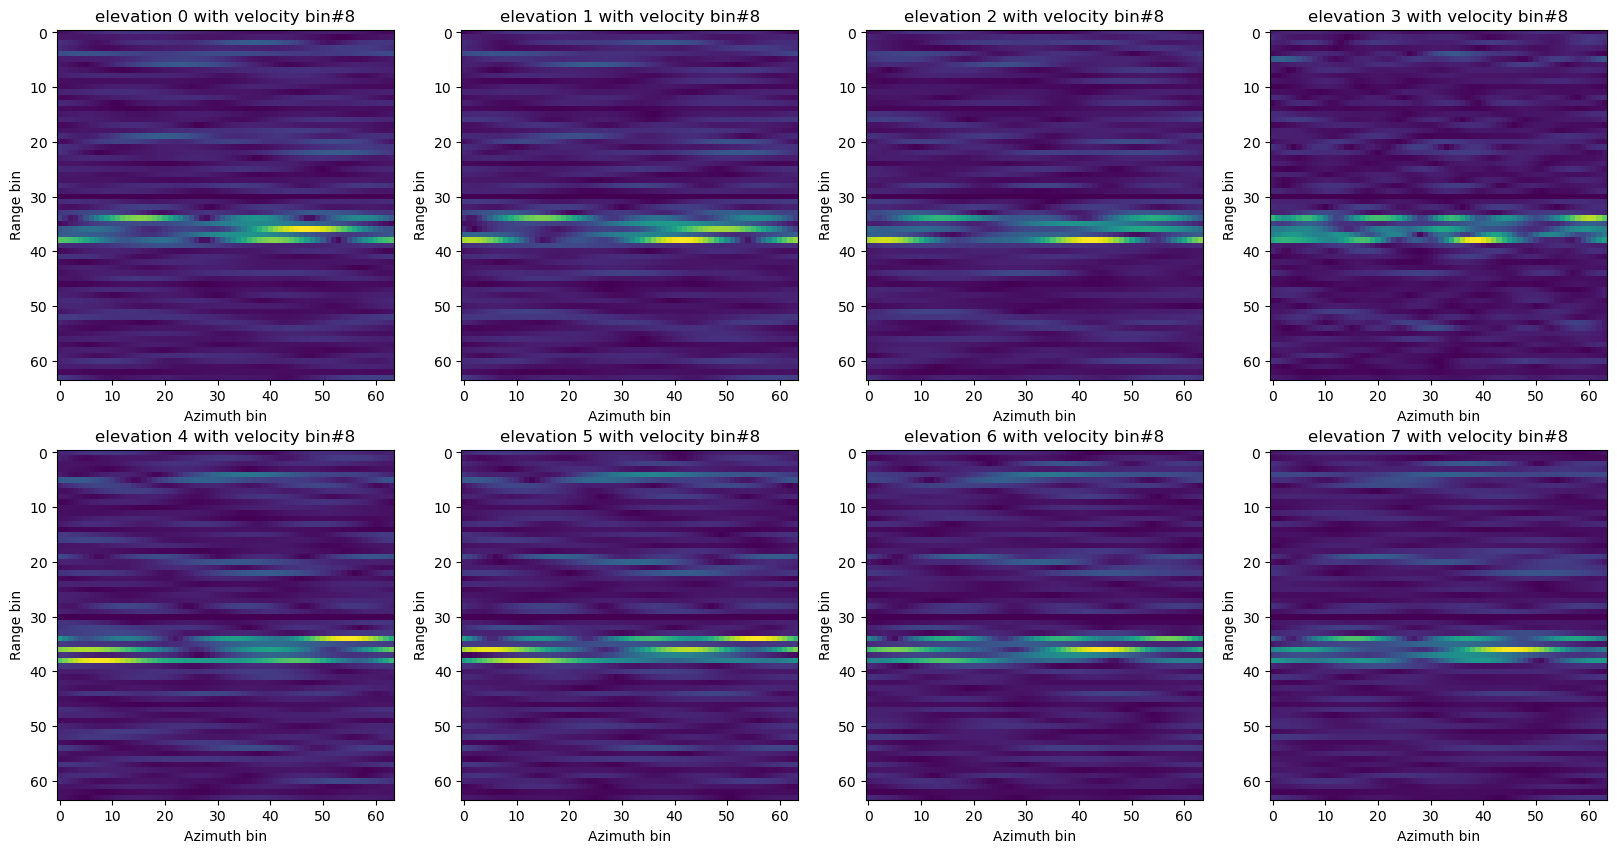

In [20]:
# visulizing the maps with velocity=0
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.abs(dataFFTGroup[8, :, :, i*4+j]), aspect='auto')
        axs[i, j].set_title(f'elevation {i*4+j} with velocity bin#8')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')

#### continue to calculate the everage of the heatmap 

In [29]:
print(dataFFTGroup.shape)

(16, 64, 64, 8)


In [30]:
# average along the last dimension
dataFFTGroup1 = np.mean(dataFFTGroup, axis=-1)
print(dataFFTGroup1.shape)

(16, 64, 64)


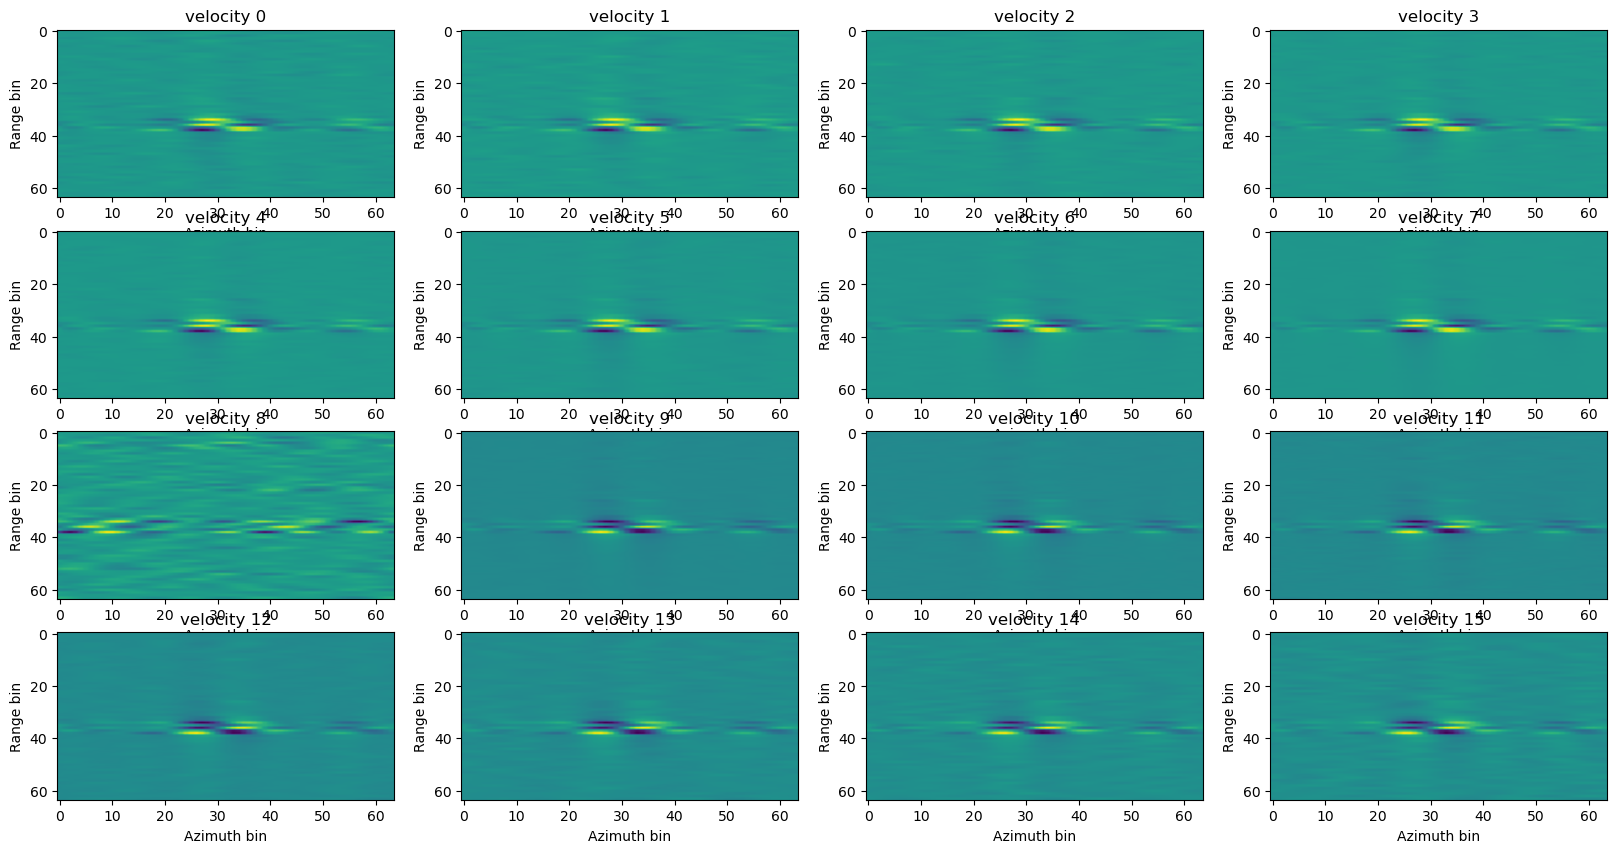

In [36]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(np.real(dataFFTGroup1[i*4+j, :, ]), aspect='auto')
        axs[i, j].set_title(f'velocity {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')
plt.show()

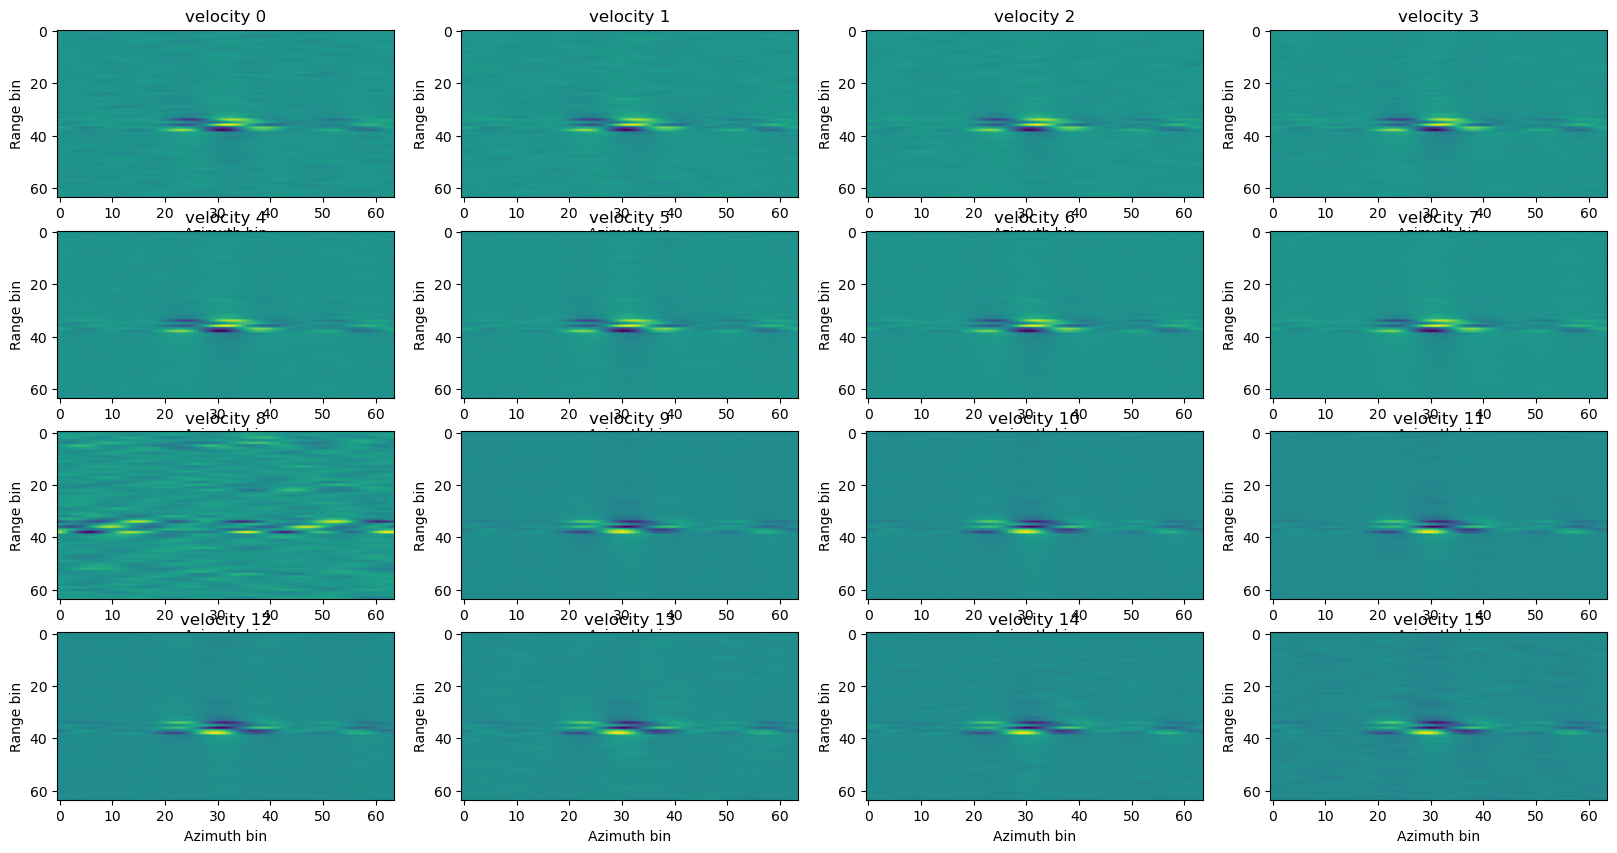

In [38]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(np.imag(dataFFTGroup1[i*4+j, :, ]), aspect='auto')
        axs[i, j].set_title(f'velocity {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')
plt.show()

Average the heatmap along the velocity axis (finally used)

In [33]:
dataFFTGroup2 = np.mean(dataFFTGroup, axis=0)
print(dataFFTGroup2.shape)


(64, 64, 8)


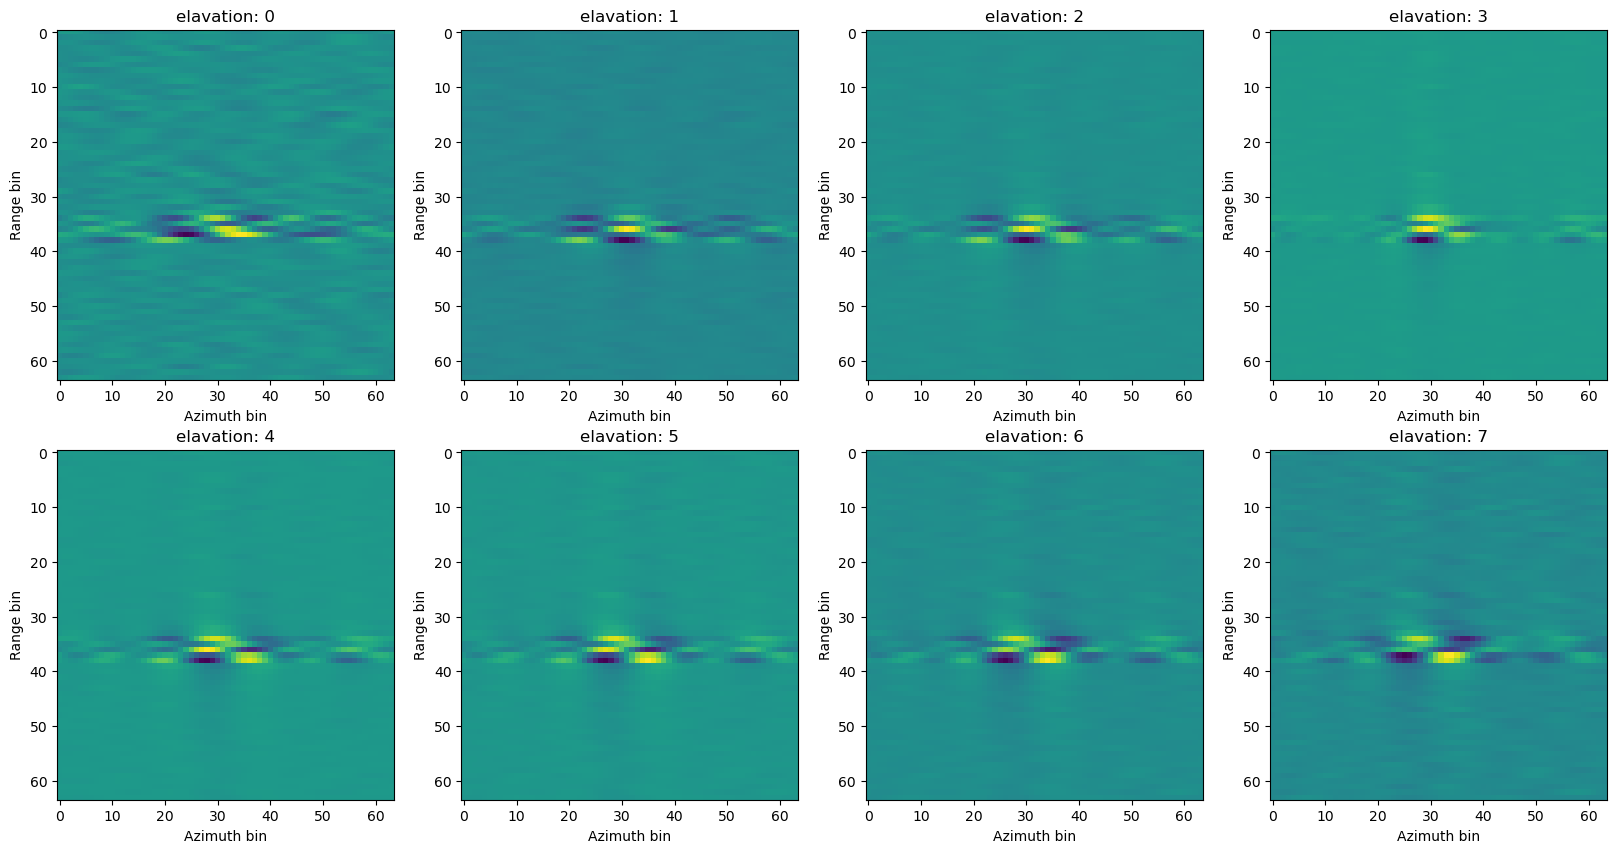

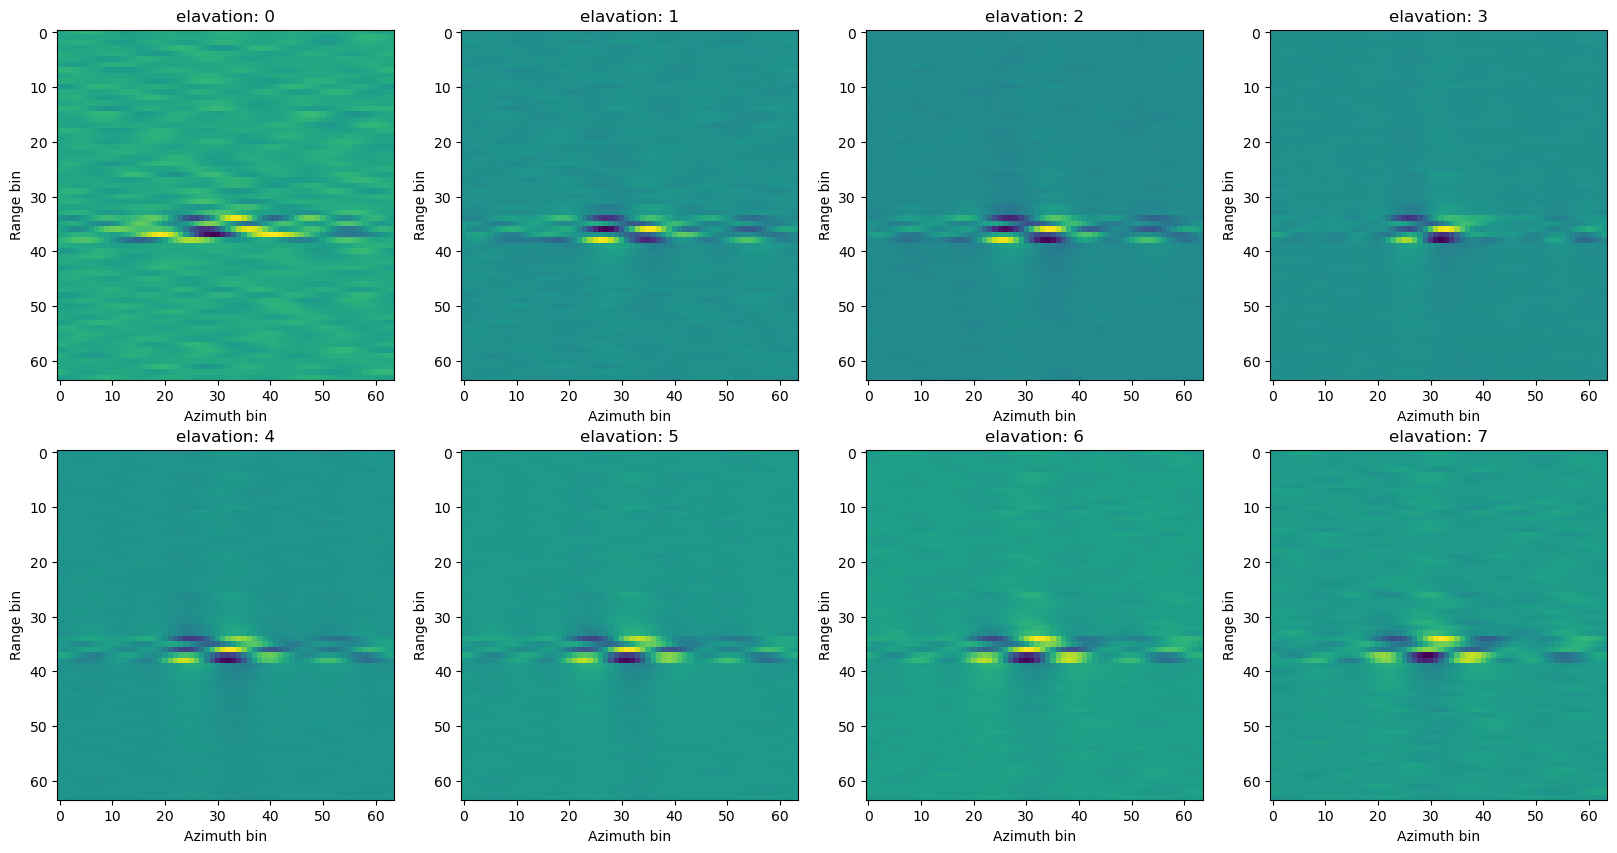

In [39]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.real(dataFFTGroup2[:, :, i*4+j]), aspect='auto')
        axs[i, j].set_title(f'elavation: {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')
plt.show()


fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.imag(dataFFTGroup2[:, :, i*4+j]), aspect='auto')
        axs[i, j].set_title(f'elavation: {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')
plt.show()

<font color='red'>Excute the preparing_dataset.py to save all the heatmap data</font>

## Checke the prepared data

Loading the pkl data

In [1]:
import pickle

with open('radar_maps/single_3.pkl', 'rb') as f:
    radar_map = pickle.load(f)

hori = radar_map['hori']
vert = radar_map['vert']
labels = radar_map['labels']    
rgb_image_folder = radar_map['rgb_image_folder']

print(len(hori))
print(len(vert))
print(len(labels))
print(rgb_image_folder)

600
600
600
frames/single_3/processed/images


In [2]:
import cv2

selected_index = 20

hori_map = hori[selected_index]
vert_map = vert[selected_index]
label = labels[selected_index]
print(rgb_image_folder + '/%09d.jpg'%(int(selected_index)))
image = cv2.imread(rgb_image_folder + '/%09d.jpg'%(int(selected_index)))


print(hori_map.shape)
print(vert_map.shape)

frames/single_3/processed/images/000000020.jpg
(64, 64, 8)
(64, 64, 8)


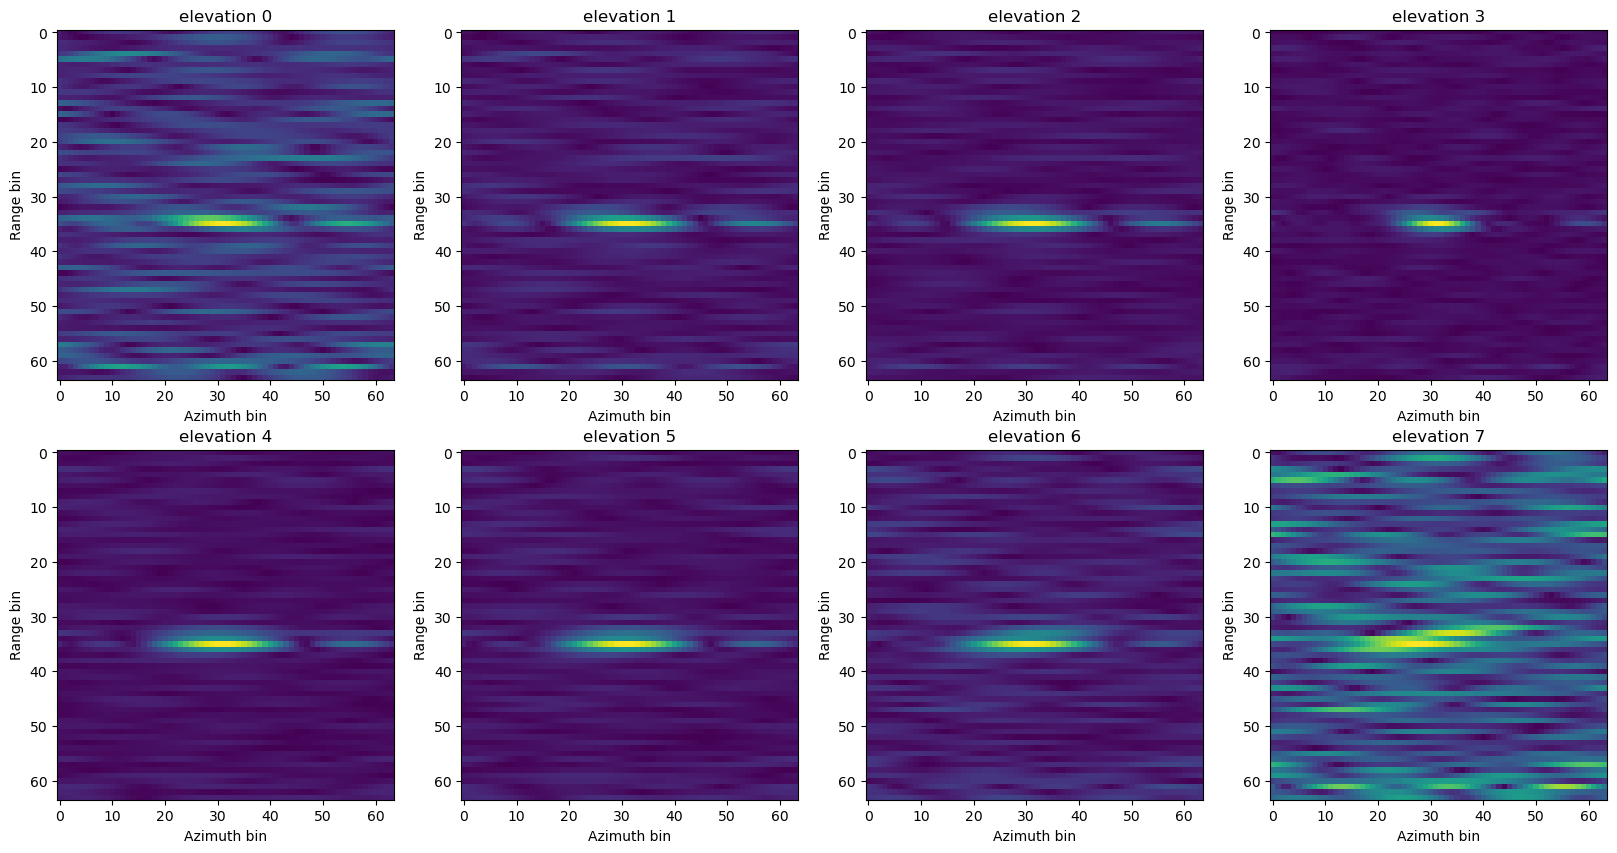

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.abs(hori_map[:, :, i*4+j]), aspect='auto')
        axs[i, j].set_title(f'elevation {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')

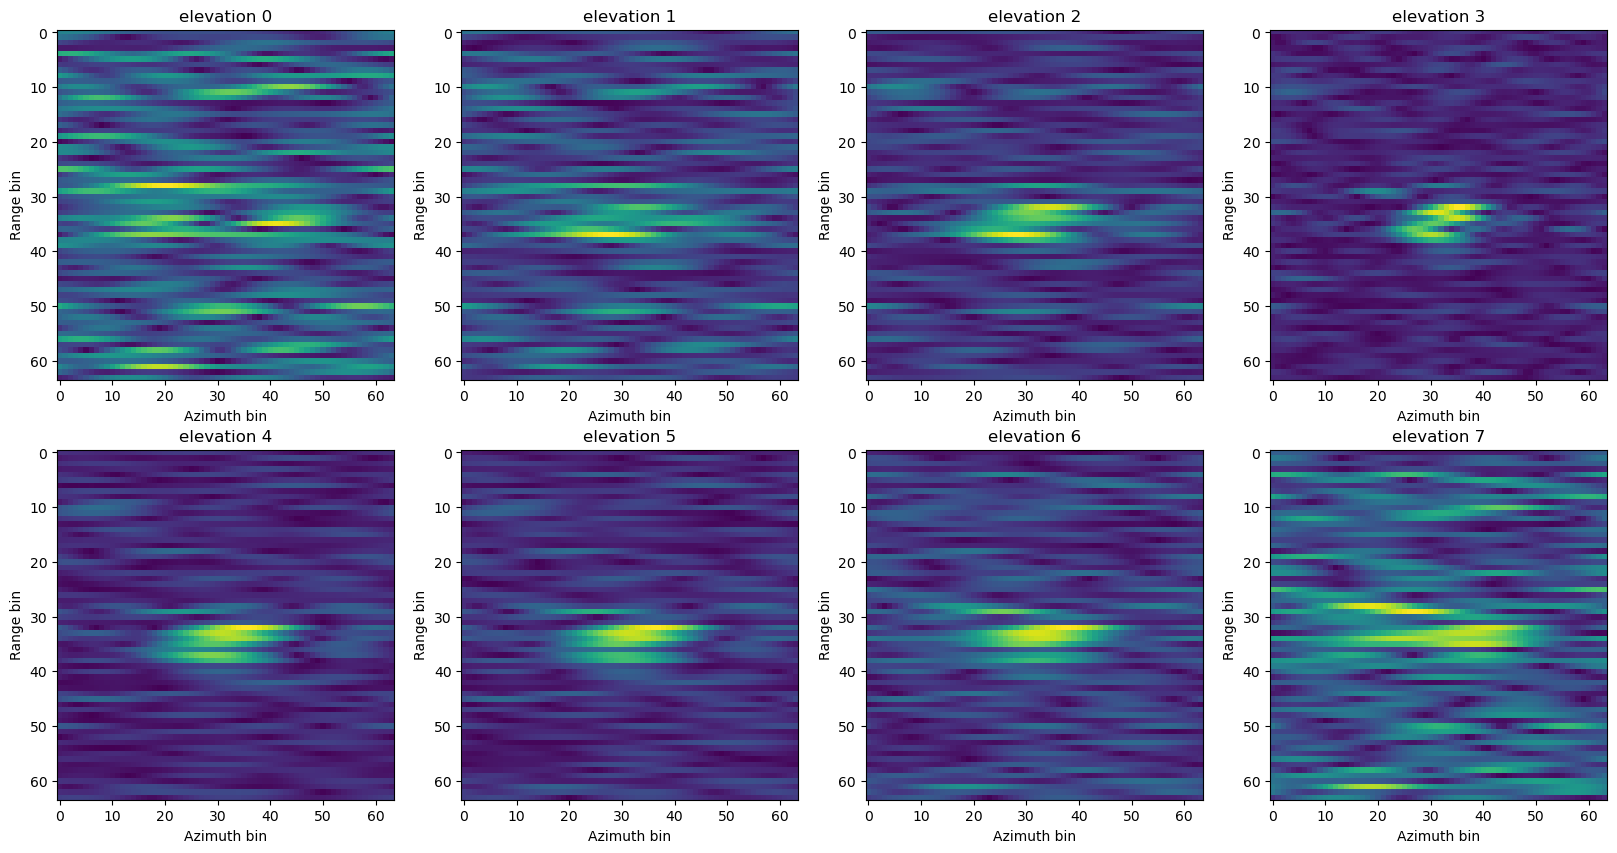

In [16]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        axs[i, j].imshow(np.abs(vert_map[ :, :, i*4+j]), aspect='auto')
        axs[i, j].set_title(f'elevation {i*4+j}')
        axs[i, j].set_xlabel('Azimuth bin')
        axs[i, j].set_ylabel('Range bin')

In [4]:
print(label.keys())
print(label['image'])
print(label['joints'])
print(label['bbox'])

dict_keys(['image', 'joints', 'bbox'])
20.jpg
[[143.7303466796875, 117.93739318847656], [143.4970703125, 159.22418212890625], [144.62286376953125, 199.65765380859375], [162.53033447265625, 117.588134765625], [157.06365966796875, 158.90225219726562], [154.056396484375, 199.6868896484375], [152.48318481445312, 48.983184814453125], [152.658203125, 22.840484619140625], [171.6873779296875, 61.694091796875], [174.69915771484375, 92.67886352539062], [175.986083984375, 120.78150939941406], [133.60894775390625, 62.048126220703125], [129.25643920898438, 92.035400390625], [129.69622802734375, 119.71591186523438]]
[121.55872344970703, 20.7449893951416, 180.01065063476562, 220.5869903564453]


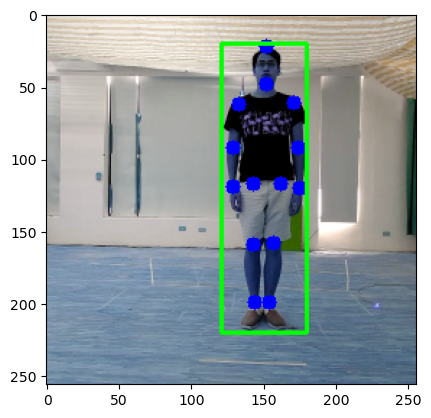

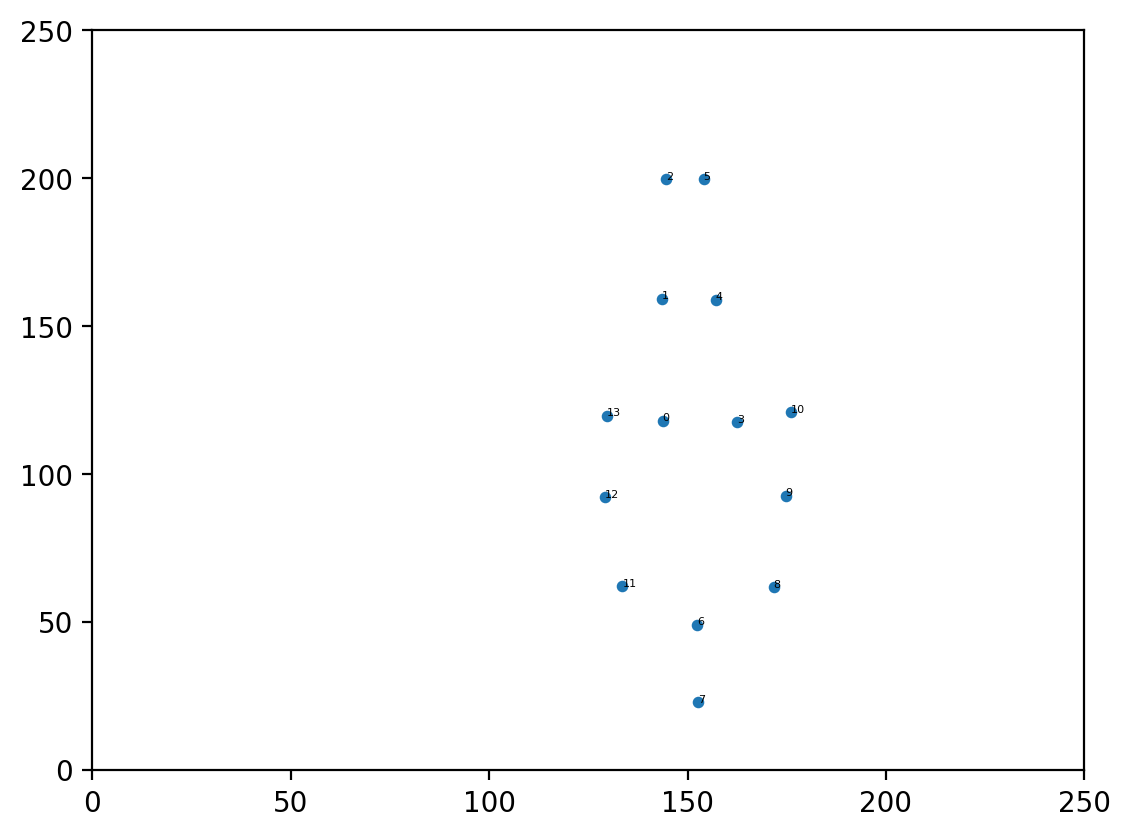

In [12]:
# draw the joints points on the image
# the joints are in the format of (x, y) in the image:  ["R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Neck", "Head", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]

label = labels[selected_index]
joints = label['joints']
bbox = label['bbox']
image = cv2.imread(rgb_image_folder + '/%09d.jpg'%(int(selected_index)))
# resize the image to 256x256
image = cv2.resize(image, (256, 256))
for joint in joints:
    cv2.circle(image, (int(joint[0]), int(joint[1])), 5, (0, 0, 255), -1)
# add the index to the joints
cv2.rectangle(image, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
plt.imshow(image)
plt.show()


fig = plt.figure(dpi=200)
ax = fig.add_subplot(111)
joints_np = np.array(joints)
ax.scatter(joints_np[:,0], joints_np[:,1], marker='o', s=10,  label='bone markers')
# put the index of the bone markers in the plot
for i in range(joints_np.shape[0]):
    ax.text(joints_np[i,0], joints_np[i,1], str(i), fontsize=4)
ax.set_xlim(0, 250)
ax.set_ylim(0, 250)
plt.show()

In [19]:
a = [(i, i+10) for i in range(4, 236, 10)]
b = a[:-2]
b.append((224, 235))
print(b)
print(len(b))

[(4, 14), (14, 24), (24, 34), (34, 44), (44, 54), (54, 64), (64, 74), (74, 84), (84, 94), (94, 104), (104, 114), (114, 124), (124, 134), (134, 144), (144, 154), (154, 164), (164, 174), (174, 184), (184, 194), (194, 204), (204, 214), (214, 224), (224, 235)]
23


In [1]:
a = [int(i) for i in range(235)]
print(a)

# random split the list a to two lists in the ratio of 0.6 and 0.4
import random
random.shuffle(a)

train = a[:int(0.6*len(a))]

test = a[int(0.6*len(a)):]

train.sort()
test.sort()
print(len(train))
print(train)
print(len(test))
print(test)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,